# Black-Scholes PDE : Explicit Finite Difference Method

---



## **Black Scholes and Market Framework**

### Risk-free Asset:
- Evolution of the Bank account :
$$
d\beta_t = r\beta_t dt,
$$
where $r \geq 0$ constant interest rate, and with $\beta_0 = 1$ we get that $\beta_t = e^{rt}$

### Risky Asset:
- The price $X_t$ follows the stochastic differential equation:
$$
dX_t = \mu X_t dt + \sigma X_t dW_t,
$$
where:
- $ \mu $ is the constant mean return,
- $ \sigma > 0 $ is the constant volatility,
- $ W_t $ is a standard Brownian motion.
- Solution :
$$
X_t = X_0 \exp\left(\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right)
$$

### Itô’s Formula:
- For a function $ g(t, X_t) $, Itô’s formula is:
$$
dg(t, X_t) = \frac{\partial g}{\partial t} dt + \frac{\partial g}{\partial x} dX_t + \frac{1}{2} \frac{\partial^2 g}{\partial x^2} d\langle X ,X \rangle_t,
$$
where $d\langle X \rangle_t = \int_0^t \sigma^2 X_s^2 ds$ is the quadratic variation.

- So :

$$
dg(t, X_t) = \left(\frac{\partial g}{\partial t} + \mu X_t \frac{\partial g}{\partial x} + \frac{1}{2} \sigma^2 X_t^2 \frac{\partial^2 g}{\partial x^2}\right)dt + \sigma X_t \frac{\partial g}{\partial x}dW_t. \tag{1}
$$

### Dynamics of the Discounted Price:
- Let $ \tilde{X}_t = e^{-rt}X_t $. Its SDE becomes:
$$
d\tilde{X}_t = (\mu - r)\tilde{X}_t dt + \sigma \tilde{X}_t dW_t.
$$

#### Important Property:
- Under the risk-neutral measure ($ \mu = r $), the discounted price becomes a **martingale**.

### Replication:
- A replicating strategy reproduces the payoff $ h(X_T) = g(T,X_T) $ of an option.
- Portfolio value:
$$
V_t = a_t X_t + b_t e^{rt} \tag{2}
$$
where $a_t$ and $b_t$ represent the quantities of risky and risk-free assets, respectively.

#### Self-Financing Condition:
$$
dV_t = a_t dX_t + r b_t e^{rt}dt \implies X_t da_t +e^{rt} db_t +d \langle a,X \rangle_t = 0
$$

So :
$$
dV_t = (\mu a_t X_t + r b_t e^{rt})dt + a_t \sigma X_t dW_t \tag{3}
$$
- Using the no-arbitrage condition :

$$
V_t = P(t, X_t)
$$

where $P(t, x)$ is the option price and $V_t$ the replicating portfolio.

By eliminating risk (or equating the $dW_t$ terms) and from (2) we get :
$$
a_t = \frac{\partial P}{\partial x} \tag{4}
$$
$$
b_t =(P−\frac{\partial P}{\partial x} X_t)e^{−rt} \tag{5}
$$

with $a_t$ is the delta and $b_t$ the value in the bank account.
### Black and Scholes PDE:

So by setting ($ \mu = r $) from (1), (3), (4) and (5) we get :

$$
\frac{\partial P}{\partial t} + \frac{1}{2} \sigma^2 X^2 \frac{\partial^2 P}{\partial x^2} + rX \frac{\partial P}{\partial x} - rP = 0,
$$

- At maturity $T$, the payoff is given by:
$$
P(T, x) = h(x).
$$


In [1]:
import pandas as pd
from datetime import *
import numpy as np
from scipy.stats import norm
import scipy.interpolate as spi
import matplotlib.pyplot as plt

class F:
    features = [
            "underlying_price",
            "strike",
            "maturity",
            "volatility",
            "interest_rate",
            "option_type",
            "black_scholes",
            "delta",
            "gamma",
            "rho",
            "theta",
            "vega",
        ]
    features_y_z = [
            "black_scholes",
            "delta",
            "gamma",
            "rho",
            "theta",
            "vega",
        ]
    underlying_price = 0
    strike = 1
    maturity = 2
    volatility = 3
    interest_rate = 4
    option_type = 5
    black_scholes = 6
    delta = 7
    gamma = 8
    rho = 9
    theta = 10
    vega = 11

### **Change of Variable:**

To study the dynamics under the logarithmic transformation $ Y_t = \ln(X_t) $, we apply **Itô's formula** to compute the derivative of $ Y_t $.

Using $ X_t = e^{Y_t} $, we calculate:
$$
dY_t = \frac{1}{X_t} dX_t - \frac{1}{2} \frac{1}{X_t^2} d\langle X, X \rangle_t.
$$

we get:
$$
dY_t = \left(r - \frac{\sigma^2}{2}\right)dt + \sigma dW_t.
$$

#### Dynamics of a function $ h(t, Y_t) $:
For a function $ h(t, Y_t) $, Itô's formula gives:
$$
dh(t, Y_t) = \frac{\partial h}{\partial t} dt + \frac{\partial h}{\partial y} dY_t + \frac{1}{2} \frac{\partial^2 h}{\partial y^2} d\langle Y, Y \rangle_t.
$$
Using $ d\langle Y, Y \rangle_t = \sigma^2 dt $, we have:
$$
dh(t, Y_t) = \left(\frac{\partial h}{\partial t} + \left(r - \frac{\sigma^2}{2}\right)\frac{\partial h}{\partial y} + \frac{1}{2}\sigma^2 \frac{\partial^2 h}{\partial y^2}\right) dt + \sigma \frac{\partial h}{\partial y} dW_t.
$$

#### Replicating Portfolio:
Define $ G(X_t) = a_t X_t + b_t e^{rt} $. Rewriting in terms of $ Y_t $:
$$
G(e^{Y_t}) = a_t e^{Y_t} + b_t e^{rt}.
$$

Using $ h(t, Y_t) = G(e^{Y_t})$, let:
$$
a_t = \frac{\partial h}{\partial y} e^{-Y_t}, \quad b_t = \left(h - \frac{\partial h}{\partial y}\right)e^{-rt}.
$$

#### Black-Scholes PDE in terms of $ Y_t $:
Substitute these relations into the dynamics, and we recover the Black-Scholes PDE for $ h(t, Y_t) $:
$$
\frac{\partial h}{\partial t} + \left(r - \frac{\sigma^2}{2}\right) \frac{\partial h}{\partial y} + \frac{1}{2}\sigma^2 \frac{\partial^2 h}{\partial y^2} = r h.
$$
At maturity $ T $, the transformed payoff is:
$$
h(T, y) = g(e^y).
$$


In [2]:
class OptionMother:
    def __init__(
        self,
        strike: float,
        underlying_price: float,
        option_type: str,
        expiry_date: str,
        interest_rate: float,
        volatility: float,
        ):
        maturity = self.compute_maturity(expiry_date)
        self.option_data = [underlying_price,
                            strike,
                            maturity,
                            volatility,
                            interest_rate,
                            option_type]

    @staticmethod
    def check_option_list(option_data: list):
        try:
            underlying_price, strike, maturity, volatility, interest_rate, option_type = option_data
        except ValueError:
            raise ValueError("The input list must have : [underlying_price,\
                                strike, maturity, volatility, \
                                interest_rate, option_type]")


    def compute_params(self, option_data: list):
        self.check_option_list(option_data)
        underlying_price, strike, maturity, volatility, interest_rate, option_type = option_data
        d1 = (1 / (volatility * np.sqrt(maturity))) * (
            np.log(underlying_price / strike)
            + ((interest_rate) + 0.5 * (volatility) ** 2) * maturity
        )
        d2 = d1 - volatility * np.sqrt(maturity)
        return d1, d2

    def compute_maturity(self, expiry_date):
        return (
            (datetime.strptime(expiry_date, "%Y-%m-%d").date() - date.today()).days
            / 365
            if datetime.strptime(expiry_date, "%Y-%m-%d").date() > date.today()
            else None
        )

    def compute_option_price(self):
        pass


### **Black-Scholes Formula**

#### European Call Option

For a European call option $g(x) = (x - K)^+$, where $K$ is the strike price. The closed-form solution is:

$$
C_{BS}(t, x; K, T; \sigma) = xN(d_1) - Ke^{-r(T-t)}N(d_2),
$$

where:
$$
d_1 = \frac{\ln(x/K) + \left(r + \frac{\sigma^2}{2}\right)(T-t)}{\sigma \sqrt{T-t}},
$$
$$
d_2 = d_1 - \sigma \sqrt{T-t},
$$


The **Delta hedging ratio** ($\Delta$) for a call option is given by:
$$
\Delta_{BS} = \frac{\partial C_{BS}}{\partial x} = N(d_1).
$$

Using the Black-Scholes formula for calls and the put-call parity relation:
$$
C_{BS}(t, x) - P_{BS}(t, x) = x - Ke^{-r(T-t)},
$$
So :
$$
P_{BS}(t, x) = Ke^{-r(T-t)}N(-d_2) - xN(-d_1),
$$

### **The Greeks**

The Greeks represent the sensitivities of the option price to various parameters. For the Black-Scholes model, these are:

#### Call Options

\begin{array}{|c|c|c|}
\hline
\textbf{Greek} & \textbf{Partial Derivative} & \textbf{Formula} \\
\hline
\Delta (\Delta) & \frac{\partial V}{\partial S} & \Delta = N(d_1) \\
\hline
\Gamma (\Gamma) & \frac{\partial^2 V}{\partial S^2} & \Gamma = \frac{1}{S \sigma \sqrt{T-t}} \phi(d_1) \\
\hline
\Theta (\Theta) & \frac{\partial V}{\partial T} & \Theta = -\frac{S \sigma}{2 \sqrt{T-t}} \phi(d_1) - r K e^{-r(T-t)} N(d_2) \\
\hline
v (\text{Vega}) & \frac{\partial V}{\partial \sigma} & v = S \sqrt{T-t} \phi(d_1) \\
\hline
\rho (\rho) & \frac{\partial V}{\partial r} & \rho = (T-t) K e^{-r(T-t)} N(d_2) \\
\hline
\end{array}

#### Put Options

Using Call-Put parity:

$$
P = C - S + K e^{-r(T-t)}
$$

We get:

\begin{array}{|c|c|c|}
\hline
\textbf{Greek} & \textbf{Relationship} & \textbf{Formula for Put} \\
\hline
\Delta (\Delta) & \Delta_{\text{put}} = \Delta_{\text{call}} - 1 & \Delta = -N(-d_1) \\
\hline
\Gamma (\Gamma) & \Gamma_{\text{put}} = \Gamma_{\text{call}} & \Gamma = \frac{1}{S \sigma \sqrt{T-t}} \phi(d_1) \\
\hline
\Theta (\Theta) & \Theta_{\text{put}} = \Theta_{\text{call}} + r K e^{-r(T-t)} & \Theta = -\frac{S \sigma}{2 \sqrt{T-t}} \phi(d_1) + r K e^{-r(T-t)} N(-d_2) \\
\hline
v (\text{Vega}) & v_{\text{put}} = v_{\text{call}} & v = S \sqrt{T-t} \phi(d_1) \\
\hline
\rho (\rho) & \rho_{\text{put}} = \rho_{\text{call}} - (T-t) K e^{-r(T-t)} & \rho = -(T-t) K e^{-r(T-t)} N(-d_2) \\
\hline
\end{array}


#### Relation Between Vega and Gamma:
The Vega and Gamma are related by:
$$
\frac{\partial P}{\partial \sigma} = (T-t)\sigma x^2 \frac{\partial^2 P}{\partial x^2}.
$$

In [3]:
class VanillaOption(OptionMother):

    def __init__(
        self,
        strike: float,
        underlying_price: float,
        option_type: str,
        expiry_date: str,
        interest_rate: float,
        volatility: float,
        ):
        super().__init__(strike, underlying_price, option_type, expiry_date, interest_rate, volatility)
        self.compute_option_price()

    def compute_option_price(self):
        self.option_price = self.black_scholes(self.option_data)

    def black_scholes(self, option_data):
        d1, d2 = self.compute_params(option_data)
        underlying_price, strike, maturity, volatility, interest_rate, option_type = option_data
        if option_type == "Call":
            return underlying_price * norm.cdf(
                d1
            ) - strike * np.exp(-interest_rate * maturity) * norm.cdf(d2)
        elif option_type == "Put":
            return - underlying_price * norm.cdf(
                -d1
            ) + strike * np.exp(-interest_rate * maturity) * norm.cdf(-d2)

    def delta(self, option_data):
        d1, d2 = self.compute_params(option_data)
        underlying_price, strike, maturity, volatility, interest_rate, option_type = option_data
        return (
            norm.cdf(d1)
            if option_type == "Call"
            else -norm.cdf(-d1)
        )

    def gamma(self, option_data):
        d1, d2 = self.compute_params(option_data)
        underlying_price, strike, maturity, volatility, interest_rate, option_type = option_data
        return (
            norm.pdf(d1)
            / (underlying_price * volatility * np.sqrt(maturity))
        )

    def theta(self, option_data):
        d1, d2 = self.compute_params(option_data)
        underlying_price, strike, maturity, volatility, interest_rate, option_type = option_data
        if option_type == "Call":
            return (
            (
                - underlying_price
                * norm.pdf(d1)
                * volatility
            )
            / (2 * np.sqrt(maturity))
            - interest_rate
            * strike
            * np.exp(-interest_rate * maturity)
            * norm.cdf(d2)
        )
        else:
            return (
            (
                - underlying_price
                * norm.pdf(d1)
                * volatility
            )
            / (2 * np.sqrt(maturity))
            + interest_rate
            * strike
            * np.exp(-interest_rate * maturity)
            * norm.cdf(-d2)

        )

    def vega(self, option_data):
        d1, d2 = self.compute_params(option_data)
        underlying_price, strike, maturity, volatility, interest_rate, option_type = option_data
        return (
            underlying_price
            * norm.pdf(d1)
            * np.sqrt(maturity)
        )

    def rho(self, option_data):
        d1, d2 = self.compute_params(option_data)
        underlying_price, strike, maturity, volatility, interest_rate, option_type = option_data
        if option_type == "Call":
            return (
            strike * maturity * np.exp(-interest_rate * maturity) * norm.cdf(d2)
        )
        else:
            return (
            -strike * maturity * np.exp(-interest_rate * maturity) * norm.cdf(-d2)
        )


#### Binary or Digital Options

A **digital option** pays a fixed amount H at maturity $T$ if the stock price $X_T \geq K$, and nothing otherwise. The payoff function if $H = 1$ is:
$$
h(x) = \mathbf{1}_{\{x \geq K\}}.
$$

The price of the digital option at time $t$ is:
$$
C_{\text{digital}}(t, x) = e^{-r(T-t)}N(d_2),
$$
Call-Put parity:
$$
C + P = e^{-r(T-t)}
$$
$$
P_{\text{digital}}(t, x) = e^{-r(T-t)}N(-d_2),
$$

### Greeks for Digital Options

#### Call options :

\begin{array}{|c|c|c|}
\hline
\textbf{Greek} & \textbf{Partial Derivative} & \textbf{Formula} \\
\hline
\Delta (\Delta) & \frac{\partial V}{\partial S} & \Delta = \frac{e^{-r(T-t)} \phi(d_2)}{S \sigma \sqrt{T-t}} \\
\hline
\Gamma (\Gamma) & \frac{\partial^2 V}{\partial S^2} & \Gamma = - \frac{e^{-r(T-t)} }{S^2 \sigma^2 (T-t)} \phi(d_2) d_1 \\
\hline
\Theta (\Theta) & \frac{\partial V}{\partial T} & \Theta = e^{-r(T-t)} \left[ r N(d_2) - \phi(d_2) \left( \frac{(r - \frac{\sigma^2}{2})}{\sigma \sqrt{T-t}} - \frac{d_2}{2(T-t)} \right) \right] \\
\hline
v (\text{Vega}) & \frac{\partial V}{\partial \sigma} & v = - \frac{e^{-r(T-t)}}{\sigma} \phi(d_2) d_1 \\
\hline
\rho (\rho) & \frac{\partial V}{\partial r} & \rho =  e^{-r(T-t)} (T-t) \left[ \phi(d_2) \frac{1}{\sigma \sqrt{T-t}} - N(d_2) \right] \\
\hline
\end{array}


#### Put Options

Using Put-Call parity:

$$
P_{\text{digital}} = e^{-r(T-t)} - C_{\text{digital}}
$$

We get:

\begin{array}{|c|c|c|}
\hline
\textbf{Greek} & \textbf{Relationship} & \textbf{Formula for Digital Put} \\
\hline
\Delta (\Delta) & \Delta_{\text{put}} = -\Delta_{\text{call}} & \Delta = -\frac{e^{-r(T-t)} \phi(d_2)}{S \sigma \sqrt{T-t}} \\
\hline
\Gamma (\Gamma) & \Gamma_{\text{put}} = -\Gamma_{\text{call}} & \Gamma = \frac{e^{-r(T-t)}}{S^2 \sigma^2 (T-t)} \phi(d_2) d_1 \\
\hline
\Theta (\Theta) & \Theta_{\text{put}} = r e^{-r(T-t)} - \Theta_{\text{call}} & \Theta = e^{-r(T-t)} \left[ r N(-d_2) + \phi(d_2) \left( \frac{(r - \frac{\sigma^2}{2})}{\sigma \sqrt{T-t}} - \frac{d_2}{2(T-t)} \right) \right] \\
\hline
v (\text{Vega}) & v_{\text{put}} = -v_{\text{call}} & v = \frac{e^{-r(T-t)}}{\sigma} \phi(d_2) d_1 \\
\hline
\rho (\rho) & \rho_{\text{put}} = -(T-t) e^{-r(T-t)} - \rho_{\text{call}} & \rho = -e^{-r(T-t)} (T-t) \left[ \phi(d_2) \frac{1}{\sigma \sqrt{T-t}} + N(-d_2) \right] \\
\hline
\end{array}


In [4]:
class BinaryOption(OptionMother):

    def __init__(
        self,
        strike: float,
        underlying_price: float,
        option_type: str,
        expiry_date: str,
        interest_rate: float,
        volatility: float,
        ):
        super().__init__(strike, underlying_price, option_type, expiry_date, interest_rate, volatility)
        self.compute_option_price()

    def compute_option_price(self):
        self.option_price = self.black_scholes(self.option_data)

    def black_scholes(self, option_data):
        d1, d2 = self.compute_params(option_data)
        underlying_price, strike, maturity, volatility, interest_rate, option_type = option_data
        if option_type == "Call":
            return np.exp(-interest_rate * maturity) * norm.cdf(d2)
        elif option_type == "Put":
            return np.exp(-interest_rate * maturity) * norm.cdf(-d2)

    def delta(self, option_data):
        d1, d2 = self.compute_params(option_data)
        underlying_price, strike, maturity, volatility, interest_rate, option_type = option_data
        return (
            np.exp(-interest_rate * maturity) * norm.pdf(d2) / (underlying_price * volatility * np.sqrt(maturity))
            if option_type == "Call"
            else -np.exp(-interest_rate * maturity) * norm.pdf(d2) / (underlying_price * volatility * np.sqrt(maturity))
        )

    def gamma(self, option_data):
        d1, d2 = self.compute_params(option_data)
        underlying_price, strike, maturity, volatility, interest_rate, option_type = option_data
        if option_type == "Call":
            return (
                - np.exp(-interest_rate * maturity)
                * norm.pdf(d2)
                * d1
                / (underlying_price * volatility * np.sqrt(maturity))**2
            )
        else:
            return (
            np.exp(-interest_rate * maturity)
                    * norm.pdf(d2)
                    * d1
                     / (underlying_price * volatility * np.sqrt(maturity))**2
            )

    def theta(self, option_data):
        d1, d2 = self.compute_params(option_data)
        underlying_price, strike, maturity, volatility, interest_rate, option_type = option_data
        tmp = (interest_rate - volatility**2/2) / (volatility * np.sqrt(maturity))
        tmp2 = d2 / (2 * maturity)
        if option_type == "Call":
            return (
                np.exp(-interest_rate * maturity) *
                (
                interest_rate
                * norm.cdf(d2)
                - norm.pdf(d2)
                * (tmp - tmp2)
            ))
        else:
            return (
                np.exp(-interest_rate * maturity) *
                (
                interest_rate
                * norm.cdf(-d2)
                + norm.pdf(d2)
                * (tmp - tmp2)
            ))

    def vega(self, option_data):
        d1, d2 = self.compute_params(option_data)
        underlying_price, strike, maturity, volatility, interest_rate, option_type = option_data
        if option_type == "Call":
            return - np.exp(-interest_rate * maturity) / volatility * norm.pdf(d2) * d1
        else:
            return np.exp(-interest_rate * maturity) / volatility * norm.pdf(d2) * d1

    def rho(self, option_data):
        d1, d2 = self.compute_params(option_data)
        underlying_price, strike, maturity, volatility, interest_rate, option_type = option_data
        if option_type == "Call":
            return (
                maturity * np.exp(-interest_rate * maturity) *
                (norm.pdf(d2) / (volatility * np.sqrt(maturity)) - norm.cdf(d2))
            )
        else:
            return - (
                maturity * np.exp(-interest_rate * maturity) *
                (norm.pdf(d2) / (volatility * np.sqrt(maturity)) + norm.cdf(-d2))
            )


In [5]:
class OptionPlot:
    def __init__(self, option):
        self.option = option

    def option_features_2D(self, x_min : int, x_max : int, feature_in_x : str, feature_in_y : str):
        if x_max < 10:
            x_features = np.arange(x_min, x_max, 0.05)
        else:
            x_features = np.arange(x_min, x_max)
        y_option_features = []
        if feature_in_x in F.__dict__:
            i = getattr(F, feature_in_x)
            for x_position in x_features:
                self.option.option_data[i] = x_position
                y_option_features.append(getattr(self.option, feature_in_y)(self.option.option_data))
            plt.plot(x_features.T, y_option_features)
            plt.xlabel(f"{feature_in_x} feature")
            plt.ylabel(f"{feature_in_y} option")
            plt.title(
                f"How {feature_in_y} option behave if {feature_in_x} feature variates at t = 0"
            )
            plt.show()

    def option_greeks_plot(self, underlying_p_min, underlying_p_max):
        x_values = np.arange(underlying_p_min,underlying_p_max)
        n_features = len(F.features_y_z)

        fig, axs = plt.subplots(2, 3, figsize=(15, 10))
        axs = axs.flatten()
        if n_features == 1:
            axs = [axs]

        for idx, feature_in_y in enumerate(F.features_y_z):
            y_values = []
            for x_val in x_values:
                self.option.option_data[F.underlying_price] = x_val
                y_value = getattr(self.option, feature_in_y)(self.option.option_data)
                y_values.append(y_value)
            axs[idx].plot(x_values, y_values)
            axs[idx].set_title(f"{feature_in_y}")
            axs[idx].set_xlabel("Price")
            axs[idx].set_ylabel(feature_in_y)
            axs[idx].grid(True)
        plt.tight_layout()
        plt.show()

    def option_features_3D(self, x_min : int, x_max : int, feature_in_x : str,
                                 y_min : int, y_max : int, feature_in_y : str,
                                 feature_in_z : str):
        if (x_max >= 10) and (y_max >= 10):
            x_features = np.arange(x_min, x_max)
            y_feature = np.arange(
                y_min, y_max, (y_max - y_min) / len(x_features)
            )
        else:
            if x_max <= 10:
                x_features = np.arange(x_min, x_max, 0.01)
                y_feature = np.arange(
                    y_min, y_max, (y_max - y_min) / len(x_features)
                )
            if y_max <= 10:
                y_feature = np.arange(y_min, y_max, 0.01)
                x_features = np.arange(
                    x_min, x_max, (x_max - x_min) / len(y_feature)
                )
        z_option_feature = np.zeros((len(x_features), len(y_feature)))
        if feature_in_x in F.__dict__:
            i = getattr(F, feature_in_x)
            j = getattr(F, feature_in_y)

            for x_position, x_feature_value in enumerate(x_features):
                self.option.option_data[i] = x_feature_value
                for y_position, y_feature_value in enumerate(y_feature):
                    self.option.option_data[j] = y_feature_value
                    z_option_feature[x_position, y_position] = getattr(self.option, feature_in_z)(self.option.option_data)

            x_features_mech, y_feature_mech = np.meshgrid(x_features, y_feature)
            fig = plt.figure()
            ax = fig.add_subplot(111, projection="3d")
            ax.plot_surface(
                x_features_mech,
                y_feature_mech,
                z_option_feature.transpose(),
                cmap="viridis",
            )
            ax.set_xlabel(f"{feature_in_x} feature")
            ax.set_ylabel(f"{feature_in_y} feature")
            ax.set_zlabel(f"{feature_in_z} option")
            ax.set_title(
                f"How {feature_in_z} option behave if {feature_in_x} and {feature_in_y} features variate"
            )
            plt.show()


#### Remind the Black-Scholes PDE :
$$
\frac{\partial h}{\partial t} + \left(r - \frac{\sigma^2}{2}\right) \frac{\partial h}{\partial x} + \frac{1}{2}\sigma^2 \frac{\partial^2 h}{\partial x^2} = r h.
$$
$$
h(T, x) = g(e^x)
$$

Now we will define it on a grid of time $\tau$ and a bounded space $\chi$:

- Time: $t_j = j\delta t$, $j = 0, 1, \dots, \text{ntime}$, with $\delta t = T / \text{ntime}$,
- Space: $x_i = X_{\min} + i\delta x$, $i = 0, 1, \dots, \text{nspace}$, with $\delta x = (X_{\max} - X_{\min}) / \text{nspace}$.

We approximate $h(j, i) \approx h(t_j, x_i)$.

On a space $\mathring{\chi}$ not bounded and using the Euler scheme:
$$
\frac{\partial h}{\partial t}(t_j, x_i) \approx \frac{h(j+1, i) - h(j, i)}{\delta t} + \mathcal{O}(\delta t)
$$

$$
\frac{\partial^2 h}{\partial x^2}(t_{j+1}, x_i) \approx \frac{h(j+1, i+1) - 2h(j+1, i) + h(j+1, i-1)}{(\delta x)^2} + \mathcal{O}((\delta x)^2)
$$

$$
\frac{\partial h}{\partial x}(t_{j+1}, x_i) \approx \frac{h(j+1, i+1) - h(j+1, i-1)}{2\delta x} + \mathcal{O}((\delta x)^2)
$$

Substituting these approximations into the PDE and group the terms involving $h(j+1, i)$, $h(j+1,i+1)$, and $h(j+1, i-1)$.

The discretized equation becomes:

$$
\begin{aligned}
&\frac{h(j+1, i) - h(j, i)}{\delta t} + \frac{\sigma^2}{2(\delta x)^2} \big[h(j+1, i+1) - 2h(j+1, i) + h(j+1, i-1)\big]  \\
&+\frac{r - \frac{\sigma^2}{2}}{2\delta x} \big[h(j+1, i+1) - h(j+1, i-1)\big] - r h(j+1, i) \\
&+\mathcal{O}(\delta t) + \mathcal{O}((\delta x)^2) = 0.
\end{aligned}
$$

$$
\text{Error} = O(\delta t) + O((\delta x)^2)
$$

Now consider the **global** error after $N = T / \delta t$ time steps. The global error is the accumulation of errors over $N$ steps for a stable scheme:
$$
\text{Global Error} \sim N \cdot \text{Error}.
$$

Since $N = T / \delta t$, we have:
$$
\text{Global Error} \sim \frac{T}{\delta t} \big(O(\delta t) + O((\delta x)^2)\big)
$$

So:
$$
\text{Global Error} \sim O(1) + O\Big(\frac{(\delta x)^2}{\delta t}\Big)
$$

The discretization parameters must satisfy that $\delta t$ and $(\delta x)^2$ are sufficiently small, and by taking $\delta t = \lambda (\delta x)^2$ such that $0 < \lambda < 1$, we get:

$$
\text{Global Error} \sim O(1) + O\Big(\frac{(\delta x)^2}{\lambda (\delta x)^2}\Big) = O(1).
$$

Since the global error is o(1), basically $\forall x_i \in \mathring{\chi}$ :

$$
\begin{aligned}
&\frac{h(j+1, i) - h(j, i)}{\delta t} + \frac{\sigma^2}{2(\delta x)^2} \big[h(j+1, i+1) - 2h(j+1, i) + h(j+1, i-1)\big]  \\
&+\frac{r - \frac{\sigma^2}{2}}{2\delta x} \big[h(j+1, i+1) - h(j+1, i-1)\big] - r h(j+1, i) \\
&+\mathcal{O}(1) = 0.
\end{aligned}
$$

The error does not grow unreasonably large under the condition that $\delta t = \lambda (\delta x)^2$. More specifically $\delta t$ and $(\delta x)^2$ should verify the CFL condition so the discretization and numerical implementation are consistent and stable to ensure convergence :

$$
C = \frac{\sigma^2 \delta t}{(\delta x)^2} < 1
$$

Rearranging terms the PDE becomes:

$$
h_{j, i} =  \left(1 - \delta t \cdot \left(r + \frac{\sigma^2}{(\delta x)^2}\right)\right) h_{j+1, i} + \delta t \left( \frac{\sigma^2}{2 (\delta x)^2} + \cdot \frac{r - \frac{\sigma^2}{2}}{2 \delta x}\right) h_{j+1, i+1} + \delta t \left(\frac{\sigma^2}{2 (\delta x)^2} - \frac{r - \frac{\sigma^2}{2}}{2 \delta x}\right) h_{j+1, i-1}
$$

#### Boundary Conditions
Taking the boundaries condition:
$$ \frac{\partial^2 h}{\partial x^2}(t_j, x_0) = \frac{\partial^2 h}{\partial x^2}(t_j, x_{n_{\text{space}}}) = 0, $$
we use non-centered estimators for the first derivative:

$$
\frac{\partial h}{\partial x}  = \frac{h_{j+1, i+1} - h_{j+1, i}}{\delta x}
$$
        
So the discretization equation becomes:

$$
\begin{aligned}
&\left(1 - \delta t \cdot \left(r + \frac{r - \frac{\sigma^2}{2}}{\delta x}\right)\right) h_{j+1, 0} + \left( \delta t \cdot \frac{r - \frac{\sigma^2}{2}}{\delta x}\right)  h_{j+1, 1} = h_{j, 0} \\
&\left(1 + \delta t \cdot \left(\frac{r - \frac{\sigma^2}{2}}{\delta x} - r \right)\right) h_{j+1, n_{\text{space}}} - \left( \delta t \cdot \frac{r - \frac{\sigma^2}{2}}{\delta x}\right) h_{j+1, n_{\text{space}}-1} = h_{j, n_{\text{space}}}
\end{aligned}
$$

By taking $ \alpha = \delta t \frac{\sigma^2}{2 (\delta x)^2} $ and $ \beta = \delta t \frac{r - \sigma^2 / 2}{2 \delta x} $ we get :

$$
\begin{aligned}
&a = 1 - 2 \alpha - r \delta t   \\
&b = (\alpha + \beta) \\
&c = (\alpha - \beta)
\end{aligned}
$$

So basically we get for $ i \in \{1,2,\dots,n_{space} - 1\}$:

$$
h_{j, i} = a \cdot h_{j+1, i} + b \cdot h_{j+1, i+1} + c \cdot h_{j+1, i-1}
$$

And for $ i \in \{0,n_{space}\}$ :

$$
\begin{aligned}
&(1 - 2 \beta - r \delta t) \cdot h_{j+1, 0} + 2 \beta \cdot h_{j+1, 1} = h_{j, 0} \\
&(1 + 2 \beta - r \delta t) \cdot h_{j+1, n_{\text{space}}} - 2 \beta \cdot h_{j+1, n_{\text{space}}-1} = h_{j, n_{\text{space}}}
\end{aligned}
$$

We can write the discretization equations for all $ i $ in matrix form as:

$$
A \cdot h_{j+1} = h_j,
$$

where $ h_{j+1} $ and $ h_j $ are vectors of the values of $ h $ at time steps $ j+1 $ and $ j $, respectively, and $ A $ is a tridiagonal matrix:

$$
A =
\begin{bmatrix}
(1 - 2 \beta - r \delta t) & 2 \beta & 0 & \cdots & 0 \\
c & a & b & \ddots  & \vdots \\
0 & \ddots & \ddots & \ddots & 0 \\
\vdots & \ddots  & c & a & b \\
0 & \cdots & 0 & - 2 \beta & (1 + 2 \beta - r \delta t)
\end{bmatrix}.
$$


#### Space bounds
We can use the formula for the space bounds:

$$
x_{\text{max/min}} = \left(r - \frac{1}{2} \sigma^2\right)T \pm k\sigma\sqrt{T}
$$

Where $ k = 3 $ or $ k = 4 $ represents a good candidate for accounting Variability.

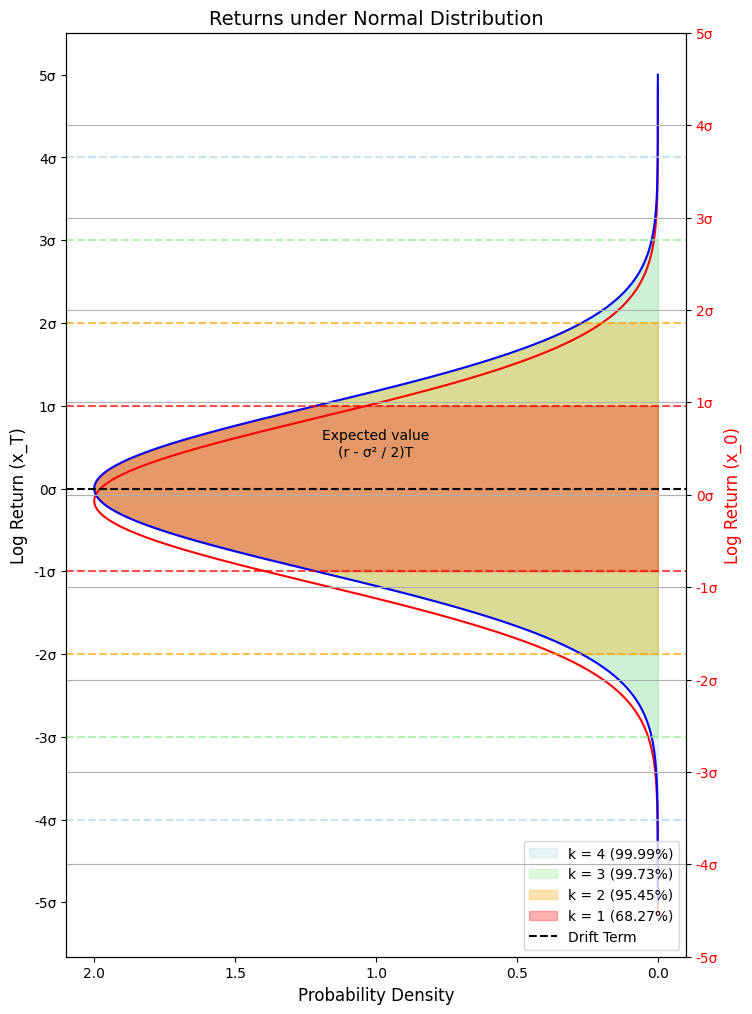

In [6]:
def plot_returns_distribution(r, sigma, T, k_values):

    mean = (r - 0.5 * sigma**2) * T
    std_dev = sigma * np.sqrt(T)

    x = np.linspace(mean - 5 * std_dev, mean + 5 * std_dev, 1000)
    y = norm.pdf(x, mean, std_dev)

    plt.figure(figsize=(8, 12))
    plt.plot(-y, x - mean, color="red")
    plt.plot(-y, x, color="blue")
    colors = ["lightblue", "lightgreen", "orange", "red"]
    for i, k in enumerate(k_values[::-1]):
        y_fill = np.linspace(-k * std_dev, k * std_dev, 1000)
        x_fill = -norm.pdf(y_fill + mean, mean, std_dev)

        plt.fill_betweenx(y_fill + mean, 0, x_fill, color=colors[i], alpha=0.3, label=f"k = {k} ({100 * norm.cdf(k) * 2 - 100:.2f}%)")

        plt.axhline(mean + k * std_dev, color=colors[i], linestyle="--", alpha=0.7)
        plt.axhline(mean -k * std_dev, color=colors[i], linestyle="--", alpha=0.7)

    plt.axhline(mean, color="black", linestyle="--", label="Drift Term")
    plt.text(min(-y) * 0.5, mean + 0.08, "Expected value\n(r - σ² / 2)T", color="black", fontsize=10, ha="center")

    y_ticks = np.arange(mean - 5 * std_dev, mean + 5 * std_dev + std_dev, std_dev)
    y_tick_labels = [f"{round((tick - mean) / std_dev)}σ" for tick in y_ticks]
    plt.yticks(y_ticks, y_tick_labels)

    x_ticks = np.linspace(-max(y), 0, len(k_values) + 1)
    x_tick_labels = np.linspace(0, max(y), len(k_values) + 1)
    x_tick_labels = [f"{round(x,1)}" for x in x_tick_labels[::-1]]
    plt.xticks(x_ticks, x_tick_labels)

    plt.ylabel("Log Return (x_T)", fontsize=12)
    plt.xlabel("Probability Density", fontsize=12)
    plt.legend(loc="lower right")
    plt.gca().twinx()
    y_ticks = np.arange(mean - 5 * std_dev, mean + 5 * std_dev + std_dev, std_dev)
    y_tick_labels = [f"{round((tick - mean) / std_dev)}σ" for tick in y_ticks]
    plt.yticks(y_ticks, y_tick_labels,c='r')
    plt.ylabel("Log Return (x_0)", fontsize=12,c='r')

    plt.title("Returns under Normal Distribution", fontsize=14)


    plt.grid(True)
    plt.show()

plot_returns_distribution(r=0.05, sigma=0.2, T=1, k_values=[1, 2, 3, 4])


The parameter $ k $ determines how many standard deviations ($ \sigma\sqrt{T} $) from the mean are considered when accounting for variability in the random variable (log return).

**Statistical Coverage :**

For a standard normal distribution ($ Z \sim N(0, 1) $), the cumulative probability of observing a value within $ k $ standard deviations from the mean is:

- $ k = 1 $, $ \pm 1 \sigma $: About 68% of outcomes.
- $ k = 2 $, $ \pm 2 \sigma $: About 95% of outcomes.
- $ k = 3 $, $ \pm 3 \sigma $: About 99.7% of outcomes.
- $ k = 4 $, $ \pm 4 \sigma $: About 99.99% of outcomes.

Using $ k = 3 $ or $ k = 4 $ captures almost all possible outcomes, making these values good candidates for accounting for large variability. In practical pricing, this provides a conservative range to accommodate extreme variations in the random variable.

**Why Not Larger $ k $?**

While $ k > 4 $ would capture even more extreme scenarios, the likelihood of such outcomes becomes negligible in most practical cases. For example $ [4\sigma, \infty] $, the probability of an outcome is approximately 0.

In [7]:
class FiniteDiff_Mother(OptionMother):

    def __init__(
        self,
        strike: float,
        underlying_price: float,
        option_type: str,
        expiry_date: str,
        interest_rate: float,
        volatility: float,
        n_space,
        k,
        ):
        super().__init__(
            strike,
            underlying_price,
            option_type,
            expiry_date,
            interest_rate,
            volatility,
        )
        self.option_data.extend([n_space, k])
        self.study_data = []


    def compute_payoff(self, x, strike, option_type):
        pass

    @staticmethod
    def check_option_list(option_data: list):
        try:
            underlying_price, strike, T, sigma, r, option_type, n_space, k = option_data
        except ValueError:
            raise ValueError("The input list must have : [underlying_price,\
                                strike, maturity, volatility, \
                                interest_rate, option_type, numb_subdiv_space, vol_range]")


    def compute_params(self, a, option_data: list):
        self.check_option_list(option_data)
        underlying_price, strike, T, sigma, r, option_type, n_space, k = option_data
        X_min = (r - sigma**2 / 2) * T - sigma * np.sqrt(T) * k
        X_max = (r - sigma**2 / 2) * T + sigma * np.sqrt(T) * k
        delta_x = (X_max - X_min) / n_space
        n_time = round(a * T*sigma**2/delta_x**2)

        delta_t = T / n_time

        n_time = n_time
        x = np.linspace(X_min, X_max, n_space + 1)
        t = np.linspace(0, T, n_time + 1)
        return delta_x, delta_t, n_time, x, t



    def black_scholes_fd(self, a, option_data):
        delta_x, delta_t, n_time, x, t = self.compute_params(a, option_data)

        underlying_price, strike, T, sigma, r, option_type, n_space, k = option_data

        strike1 = strike / underlying_price

        alpha = delta_t * sigma**2 / (2 * delta_x**2)
        beta = delta_t * (r - sigma**2 / 2) / (2 * delta_x)
        a_i = 1 - 2 * alpha - r * delta_t
        b_i = alpha + beta
        c_i = alpha - beta
        A = np.zeros((n_space + 1, n_space + 1))
        np.fill_diagonal(A[1:-1, 1:-1], a_i)
        np.fill_diagonal(A[1:, 2:], b_i)
        np.fill_diagonal(A[1:-1, :-2], c_i)

        A[0, 0] = 1 - 2 * beta - r * delta_t
        A[0, 1] = 2 * beta
        A[-1, -1] = 1 + 2 * beta - r * delta_t
        A[-1, -2] = - 2 * beta

        h = self.compute_payoff(x, strike1, option_type)
        option_prices = np.zeros((n_time + 1, n_space + 1))
        option_prices[n_time] = h
        for i in range(n_time-1,-1,-1):
            h = A @ h
            option_prices[i] = h
        # Here I suppose that x represents return at time t = 0 so basically
        stock_prices = np.exp(x)
        # The stock price moved through time from E[exp(x_0)] = 1 to E[exp(x_T)] = exp(r * T)
        # I search in the same manner in bakcward
        #So I will get the index that presents the E[exp(x_0)] and will get the E[Option_0] through the same index
        # I will interpolate
        inter = spi.splrep( stock_prices, h, k=1 )
        option_price = spi.splev( 1, inter)
        self.study_data = [option_prices, delta_t, delta_x, stock_prices, t]
        return option_price

    def plot_gamma_matrix(self, t_max):
        option_prices, delta_t, delta_x, stock_prices, t = self.study_data
        ti_max = np.argmin(t<=t_max)
        ti_max = ti_max if ti_max>0 else len(t) - 1
        gamma = (option_prices[:,:-2] - 2 * option_prices[:,1:-1] + option_prices[:,2:]) / self.option_data[F.underlying_price]/(stock_prices[2:] - stock_prices[:-2])**2
        X, T = np.meshgrid(stock_prices[2:], t[:ti_max])
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(T, X, gamma[:ti_max], cmap='viridis')
        ax.set_title('3d plot of Gamma through time')
        ax.set_xlabel('Time')
        ax.set_ylabel('Stock price in %')
        ax.set_zlabel('Gamma')
        plt.show()


    def plot_theta_matrix(self, t_max):
        option_prices, delta_t, delta_x, stock_prices, t = self.study_data
        ti_max = np.argmin(t<=t_max)
        ti_max = ti_max if ti_max>0 else len(t) - 1
        theta = (option_prices[1:] - option_prices[:-1]) / delta_t
        X, T = np.meshgrid(stock_prices, t[1:ti_max])
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(T, X, theta[:ti_max-1], cmap='viridis')
        ax.set_title('3d plot of Theta')
        ax.set_xlabel('Time')
        ax.set_ylabel('Stock price in %')
        ax.set_zlabel('Theta')
        plt.show()

    def plot_delta_matrix(self, t_max):
        option_prices, delta_t, delta_x, stock_prices, t = self.study_data
        ti_max = np.argmin(t<=t_max)
        ti_max = ti_max if ti_max>0 else len(t) - 1
        deltas = (option_prices[:,1:] - option_prices[:,:-1]) / self.option_data[F.underlying_price] / (stock_prices[1:] - stock_prices[:-1])
        X, T = np.meshgrid(stock_prices[:-1], t[:ti_max])
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(T, X, deltas[:ti_max], cmap='viridis')
        ax.set_title('3d plot of Delta through time')
        ax.set_xlabel('Time')
        ax.set_ylabel('Stock price in %')
        ax.set_zlabel('Delta')
        plt.show()

    def plot_solution_matrix(self):
        option_prices, delta_t, delta_x, stock_prices, t = self.study_data
        X, T = np.meshgrid(stock_prices, t)
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(T, X, option_prices, cmap='viridis')
        ax.set_title('3d plot of the Solution to the Option price through time')
        ax.set_xlabel('Time')
        ax.set_ylabel('Stock price in %')
        ax.set_zlabel('Option price in %')
        plt.show()


In [8]:
class FD_Vanilla(FiniteDiff_Mother):

    def compute_option_price(self, a : int):
        self.option_price = self.black_scholes_fd(a, self.option_data) * self.option_data[F.underlying_price]

    def compute_payoff(self, x, strike, option_type):
        if option_type == "Call":
            return np.maximum(np.exp(x) - strike, 0)
        return np.maximum(strike - np.exp(x), 0)

In [9]:
class FD_Binary(FiniteDiff_Mother):

    def compute_option_price(self, a : int):
        self.option_price = self.black_scholes_fd(a, self.option_data)

    def compute_payoff(self, x, strike, option_type):
        if option_type == "Call":
            return np.where(np.exp(x) >= strike, 1, 0)
        return np.where(np.exp(x) <= strike, 1, 0)

## Convergence and Divergence under the Variability of C = $ \frac{\sigma^2 \delta t }{(\delta x)^2} $

In [10]:
strike = 255
underlying_price = 255
option_type = "Call"
expiry_date = "2025-03-22"
interest_rate = 0.04
implied_vol = 0.2

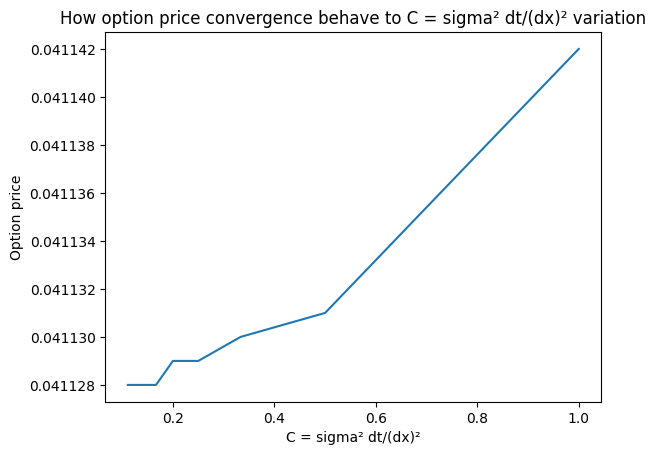

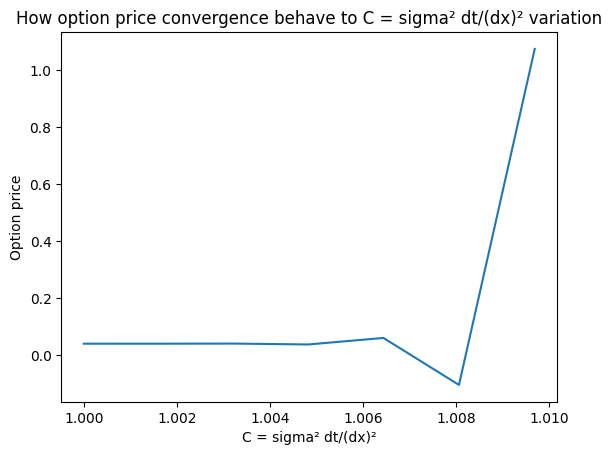

In [11]:
def test_convergence(fd_option,a_min,a_max,a_step):
    convergence = [[],[],[]]
    for a in np.arange(a_min,a_max,a_step):
        delta_x, delta_t, n_time, x, t = fd_option.compute_params(a, fd_option.option_data)
        option_price = fd_option.black_scholes_fd(a, fd_option.option_data)
        constant = delta_t * fd_option.option_data[F.volatility]**2 / delta_x**2
        convergence[0].append(constant)
        convergence[1].append(np.round(option_price,6))
        convergence[2].append(a)

    convergence = pd.DataFrame(np.transpose(convergence), columns = ["constant","price_convergence","a_control"])
    plt.plot(convergence.constant, convergence.price_convergence)
    plt.xlabel("C = sigma² dt/(dx)²")
    plt.ylabel("Option price")
    plt.title(
        f"How option price convergence behave to C = sigma² dt/(dx)² variation"
    )
    plt.show()

convergent_option = FD_Vanilla(strike, underlying_price, option_type, expiry_date, interest_rate, implied_vol, 200, 4)
test_convergence(convergent_option,1,10,1)
test_convergence(convergent_option,0.99,1,0.001)

## First Plot ($C \leq 1$)
- The option price remains **stable and convergent** within this range.
- Variations in the price are small, on the order of $10^{-6}$.

## Second Plot ($C > 1$)
- The option price becomes **unstable and diverges** when $C > 1$.
- Sharp oscillations and erratic behavior start around $C = 1.008$.

The  condition ($C \leq 1$) ensures numerical stability and reliable results.

In [12]:
underlying_price = 255
expiry_date = "2025-03-22"
interest_rate = 0.04
implied_vol = 0.2

n_space, k, a = [300, 4, 2]

strikes = np.arange(250, 265, 5)

def calculate_accuracy(bs_price, fd_price):
    error = abs(fd_price / bs_price - 1) * 100 if bs_price != 0 else None
    return error

call_data = []
put_data = []

for strike in strikes:
    call_vanilla = VanillaOption(strike, underlying_price, "Call", expiry_date, interest_rate, implied_vol)
    call_bs = call_vanilla.option_price

    call_fd = FD_Vanilla(strike, underlying_price, "Call", expiry_date, interest_rate, implied_vol, n_space, k)
    call_fd.compute_option_price(a)
    call_fd_price = call_fd.option_price

    call_error = calculate_accuracy(call_bs, call_fd_price)
    call_data.append([call_bs, call_fd_price, call_error])

    put_vanilla = VanillaOption(strike, underlying_price, "Put", expiry_date, interest_rate, implied_vol)
    put_bs = put_vanilla.option_price

    put_fd = FD_Vanilla(strike, underlying_price, "Put", expiry_date, interest_rate, implied_vol, n_space, k)
    put_fd.compute_option_price(a)
    put_fd_price = put_fd.option_price

    put_error = calculate_accuracy(put_bs, put_fd_price)
    put_data.append([put_bs, put_fd_price, put_error])

call_df = pd.DataFrame(
    call_data, columns=["Black-Scholes", "Finite Difference", "Error %"], index=strikes
)
put_df = pd.DataFrame(
    put_data, columns=["Black-Scholes", "Finite Difference", "Error %"], index=strikes
)

print(f"Vanilla call option with different strikes: \n {call_df}")
print(f"Vanilla put option with different strikes: \n {put_df}")

Vanilla call option with different strikes: 
      Black-Scholes  Finite Difference   Error %
250      13.266799          13.267585  0.005926
255      10.487296          10.488178  0.008414
260       8.125228           8.125860  0.007783
Vanilla put option with different strikes: 
      Black-Scholes  Finite Difference   Error %
250       6.138920           6.139715  0.012960
255       8.316859           8.317751  0.010722
260      10.912234          10.912875  0.005880


## Vanilla Options
- **Call Options**:
  - Errors are extremely small (maximum $0.0063\%$) due to the smooth payoff structure.
  - The finite difference method matches Black-Scholes closely, showing high reliability.

- **Put Options**:
  - Errors are slightly higher (maximum $0.0136\%$) but still very small.
  - Minor differences may arise from boundary condition sensitivity in the finite difference method.


In [13]:
call_data = []
put_data = []

for strike in strikes:
    call_binary = BinaryOption(strike, underlying_price, "Call", expiry_date, interest_rate, implied_vol)
    call_bs = call_binary.option_price

    call_fd = FD_Binary(strike, underlying_price, "Call", expiry_date, interest_rate, implied_vol, n_space, k)
    call_fd.compute_option_price(a)
    call_fd_price = call_fd.option_price

    call_error = calculate_accuracy(call_bs, call_fd_price)
    call_data.append([call_bs, call_fd_price, call_error])

    put_binary = BinaryOption(strike, underlying_price, "Put", expiry_date, interest_rate, implied_vol)
    put_bs = put_binary.option_price

    put_fd = FD_Binary(strike, underlying_price, "Put", expiry_date, interest_rate, implied_vol, n_space, k)
    put_fd.compute_option_price(a)
    put_fd_price = put_fd.option_price

    put_error = calculate_accuracy(put_bs, put_fd_price)
    put_data.append([put_bs, put_fd_price, put_error])

call_df = pd.DataFrame(
    call_data, columns=["Black-Scholes", "Finite Difference", "Error %"], index=strikes
)
put_df = pd.DataFrame(
    put_data, columns=["Black-Scholes", "Finite Difference", "Error %"], index=strikes
)

print(f"Binary call option with different strikes: \n {call_df}")
print(f"Binary put option with different strikes: \n {put_df}")

Binary call option with different strikes: 
      Black-Scholes   Finite Difference   Error %
250       0.597598  0.5948780830996262  0.455082
255       0.514023  0.5115590186961408  0.479330
260       0.431242  0.4275288040122112  0.861138
Binary put option with different strikes: 
      Black-Scholes    Finite Difference   Error %
250       0.393891  0.39661038862309506  0.690431
255       0.477466  0.47992945302657997  0.516027
260       0.560246   0.5639596677105095  0.662848


## Binary Options
- **Call Options**:
  - Errors range from $0.35\%$ to $1.01\%$, increasing with strike prices.
  - We could say that the larger errors are due to the **discontinuous payoff structure** of binary options.

- **Put Options**:
  - Errors range from $0.59\%$ to $0.78\%$, slightly increasing with strike prices.
  - Sensitivity near the strike price leads to greater numerical instability.

## Interpretation
- The finite difference method is **reliable** for vanilla options with an error of $ 0.1 \%$.
- For binary options, it remains acceptable but shows greater difficulty due to the payoff discontinuity with an error growing to $1 \%$.
# Delta and Gamma for Binary Option

In [14]:
underlying_price = 255
expiry_date = "2025-03-22"
interest_rate = 0.04
implied_vol = 0.2
option_type = 'Call'
strike = 255
n_space, k, a = [300, 4, 10]

c_fd_binary = FD_Binary(strike, underlying_price, option_type, expiry_date, interest_rate, implied_vol, n_space, k)
c_fd_binary.compute_option_price(a)

## Price Behavior

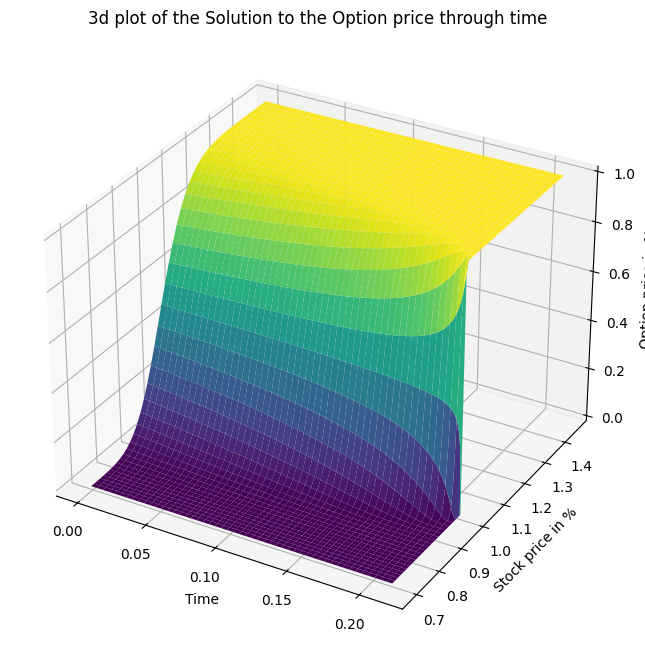

In [15]:
c_fd_binary.plot_solution_matrix()

### Interpretations
- The price of a binary option changes smoothly from 0 to 1 as the underlying price surpasses the strike price. It changes near the strike price, indicating that the derivative (Delta) is maximized there.
- The limit of the price as the underlying becomes significantly ITM ($ S \gg K $) or OTM ($ S \ll K $) converges to 1 and 0, respectively.
- ITM is convex and OTM is concave. The 3D plot shows time as an additional dimension, the option price approaches its intrinsic value over time, and the price curve becomes discontinuous, emphasizing the binary nature of payout at expiration.

## Delta behavior

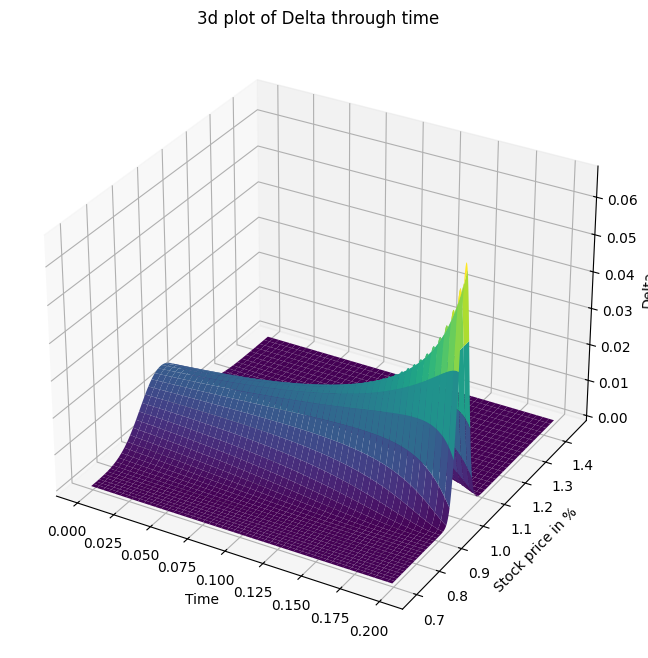

In [16]:
#Change through time
c_fd_binary.plot_delta_matrix(1/5)

### Interpretations
- Delta measures the sensitivity or speed as the first derivative of the option price to changes in the underlying price. It peaks around the strike price, reflecting the largest price sensitivity for ATM options. Its behavior is non-monotonic: it increases for OTM options as $ S \to K $ and decreases for ITM options as $ S > K $, describing the option price convexity.
- As time passes, the Delta function sharpens and its peak heightens reflecting the discontinuity at $ S = K $, which becomes more pronounced with decreasing time to maturity.
In conclusion, then delta tends to zero on the right and on the left of the strike price, while it will tend to infinity at the strike price when the time to expiry tends to zero.

## Gamma Behavior

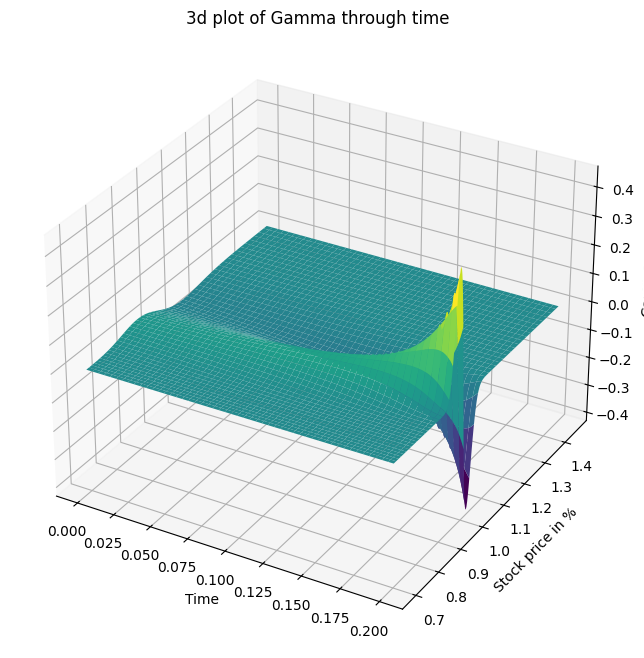

In [17]:
#Change through time
c_fd_binary.plot_gamma_matrix(1/5)

### Interpretations
- **Out-of-the-Money (OTM)**: Gamma is **positive**, reflecting increasing Delta as $ S \to K $.
- **At-the-Money (ATM)**: Gamma = 0 maximum Delta.
- **In-the-Money (ITM)**: Gamma is **negative**, as price converges (acceleration negative $\implies$ lower speed) to 1 beyond $ S = K $.
- Gamma becomes sharper and more concentrated around $ S = K $ as time to maturity decreases.

## All Greeks :

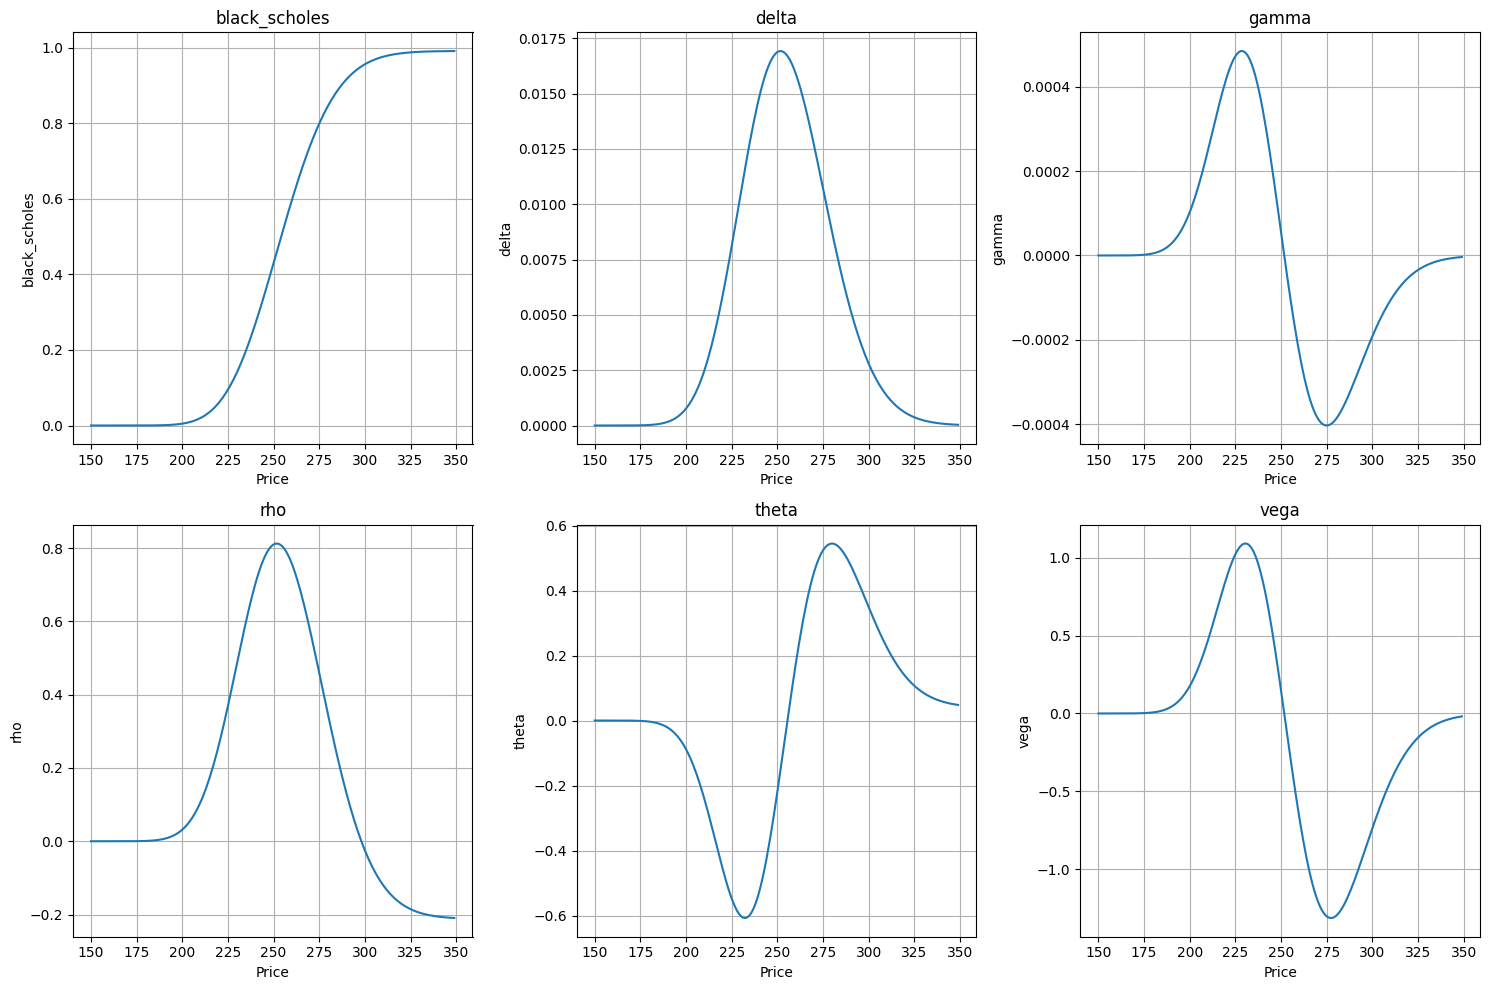

In [18]:
c_binary = BinaryOption(strike, underlying_price, option_type, expiry_date, interest_rate, implied_vol)
c_binary_plot = OptionPlot(c_binary)
c_binary_plot.option_greeks_plot(150,350)

# Long Straddle Strategy using Binary Options

In [19]:
underlying_price = 255
expiry_date = "2025-03-22"
interest_rate = 0.04
implied_vol = 0.2
option_type = 'Call'
strike = 250
n_space, k, a ,strike_put= [300, 4, 10,260]

In [20]:
class FD_Binary_LStraddle(FiniteDiff_Mother):

    def __init__(
        self,
        strike_call: float,
        strike_put : float,
        underlying_price: float,
        option_type: str,
        expiry_date: str,
        interest_rate: float,
        volatility: float,
        n_space,
        k,
        ):
        super().__init__(
            strike_call,
            underlying_price,
            option_type,
            expiry_date,
            interest_rate,
            volatility,
            n_space,
            k,
        )
        self.option_data.extend([strike_put])
        self.study_data = []

    def compute_option_price(self, a : int):
        self.option_price = self.black_scholes_fd(a, self.option_data[:-1])

    def compute_payoff(self, x, strike_call, option_type):
        strike2 = self.option_data[-1] / self.option_data[F.underlying_price]
        return np.where(np.exp(x) >= strike_call, 1, 0) + np.where(np.exp(x) <= strike2, 1, 0)

    def plot_pnl_matrix(self):
        self.compute_option_price(5)
        option_prices, delta_t, delta_x, stock_prices, t = self.study_data
        borrow = self.option_price * np.ones((len(stock_prices),1))
        borrow = np.transpose(np.transpose([borrow]*len(t))*(np.exp(self.option_data[F.interest_rate]*t)))[:,:,0]
        option_pnl = option_prices.copy()
        option_pnl[0] = borrow[0] - option_pnl[0]
        option_pnl[1:] = option_pnl[1:] - borrow[1:]
        X, T = np.meshgrid(stock_prices, t)
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(T, X, option_pnl, cmap='viridis')
        ax.set_title('3d plot of the Solution to the Option price through time')
        ax.set_xlabel('Time')
        ax.set_ylabel('Stock price in %')
        ax.set_zlabel('Option price in %')
        plt.show()
        fig, axs = plt.subplots(1, 3, figsize=(10, 6))
        axs[0].plot(stock_prices, option_pnl[0], label="Time 0")
        axs[0].set_title("Cashflow at Time 0")
        axs[0].set_xlabel("Stock Prices")
        axs[0].set_ylabel("Potfolio P&L")
        axs[0].legend()

        axs[1].plot(stock_prices, -option_prices[0], label="Time 0")
        axs[1].set_title("What You Pay")
        axs[1].set_xlabel("Stock Prices")
        axs[1].set_ylabel("Price to Pay")
        axs[1].legend()

        axs[2].plot(stock_prices, borrow[0], label="Time 0")
        axs[2].set_title("How much to borrow")
        axs[2].set_xlabel("Stock Prices")
        axs[2].set_ylabel("Money")
        axs[2].legend()
        fig, axs = plt.subplots(1, 3, figsize=(12, 8))
        axs[0].plot(stock_prices, option_pnl[-1], label="Expiration")
        axs[0].set_title("P&L at expiry")
        axs[0].set_xlabel("Stock Prices")
        axs[0].set_ylabel("Portfolio P&L")
        axs[0].legend()

        axs[1].plot(stock_prices, option_prices[-1], label="Expiration")
        axs[1].set_title("Payoff of the option")
        axs[1].set_xlabel("Stock Prices")
        axs[1].set_ylabel("Option price")
        axs[1].legend()

        axs[2].plot(stock_prices, -borrow[-1], label="Expiration")
        axs[2].set_title("How much to give back to bank")
        axs[2].set_xlabel("Stock Prices")
        axs[2].set_ylabel("Money")
        axs[2].legend()

        plt.tight_layout()
        plt.show()

In [21]:
c_fd_binary = FD_Binary_LStraddle(strike,strike_put, underlying_price, option_type, expiry_date, interest_rate, implied_vol, n_space, k)
c_fd_binary.option_data[F.maturity] = 1/52
c_fd_binary.compute_option_price(a)

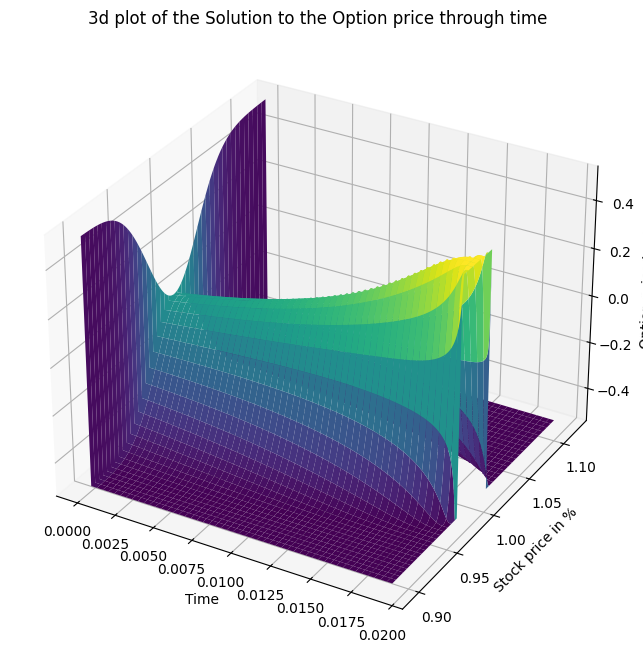

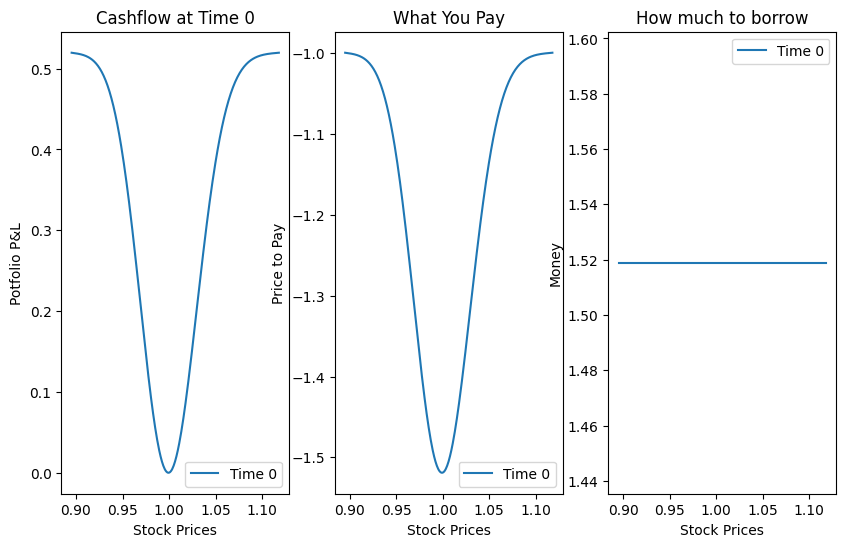

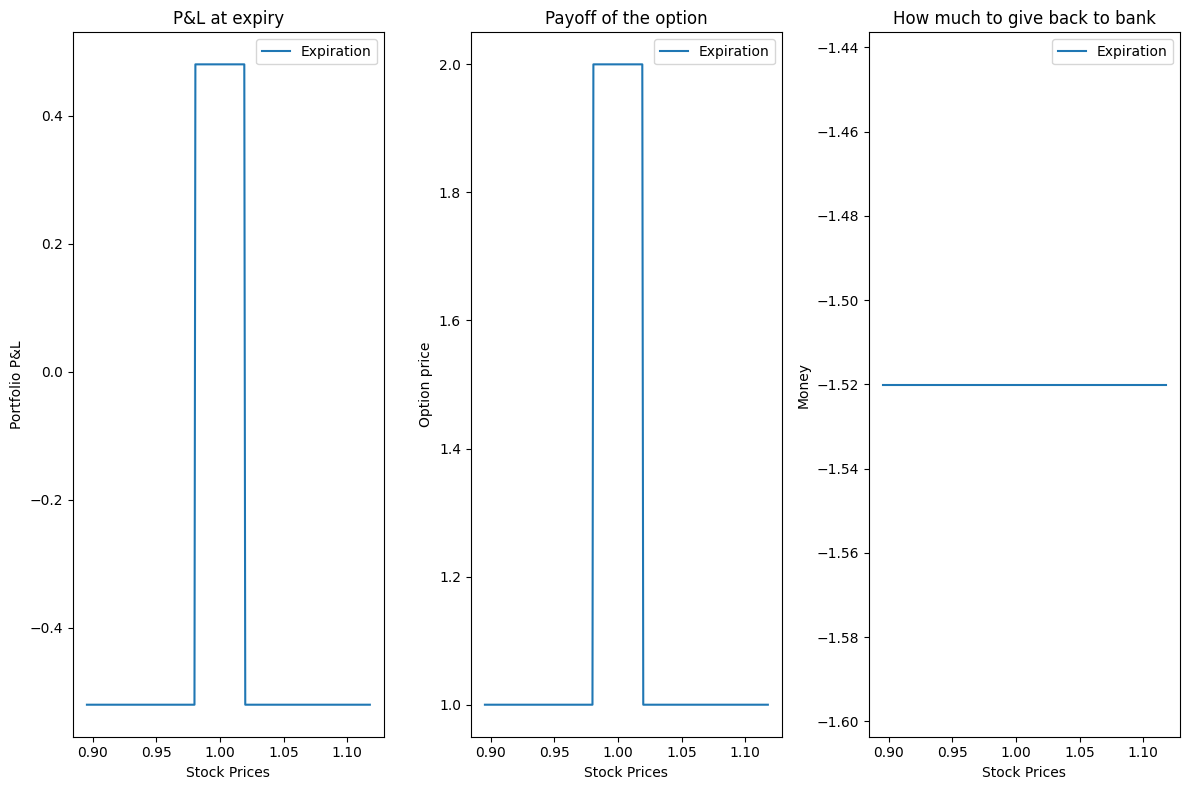

In [22]:
c_fd_binary.plot_pnl_matrix()

1. **Concept**:
   - Exploits price movements within a range by identifying tops (*resistance levels*) and bottoms (*support levels*).
   - Open a **PUT option** at the top and a **CALL option** at the bottom of the price range.

2. **Effectiveness**:
   - Works best in **low-volatility conditions**, where the price trades in a tight range.

3. **Steps**:
   - **Identify Levels**: Confirm the resistance and support range.
   - **Execute Trades**: Place:
     - **Long PUT options** at resistance.
     - **Long CALL options** at support.
     - **Short two zero coupons with V_0 is the sum of both prices C&P**
4. **Analysis**:
- When the stock price < 250 or stock price > 260 the P&L is near -0.5.
- When the 260 > stock price > 250  the P&L is near 0.5.
- So basically if the stock price Stays in the interval defined by the **Resistance and Support strikes for Long P&C respectively** the P&L using this strategy is 50%.
- So in general for the less volatile markets this strategy may work by good definition of the **Resistance and Support**.